In [1]:
from gensim.models import FastText

# Load pre-trained FastText models for English and Hindi
def load_fasttext_model(language):
    # Gensim's FastText model loading
    model = FastText.load_fasttext_format(f'bin_models/cc.{language}.300.bin/cc.{language}.300.bin')  # Assuming you have the FastText binary
    return model

# Load models
en_model = load_fasttext_model('en')
hi_model = load_fasttext_model('hi')

C:\Users\hseng\AppData\Local\Temp\ipykernel_14224\679741316.py:6: DeprecationWarning: Call to deprecated `load_fasttext_format` (use load_facebook_vectors (to use pretrained embeddings) or load_facebook_model (to continue training with the loaded full model, more RAM) instead).
  model = FastText.load_fasttext_format(f'bin_models/cc.{language}.300.bin/cc.{language}.300.bin')  # Assuming you have the FastText binary


In [2]:
bilingual_lexicon = []
with open('english-hindi-full-bilingual-lexicon.txt', 'r', encoding='utf-8') as f:
    for line in f:
        en_word, hi_word = line.strip().split('\t')
        bilingual_lexicon.append((en_word, hi_word))

len(bilingual_lexicon)

38221

In [52]:
en_model.wv.most_similar('hello')

[('hellow', 0.7143729329109192),
 ('hello.', 0.709537148475647),
 ('hi', 0.7038338780403137),
 ('hullo', 0.6944327354431152),
 ('hello-', 0.6912143230438232),
 ('Hello', 0.6639763116836548),
 ('hello.I', 0.6563244462013245),
 ('howdy', 0.6529380679130554),
 ('hellooo', 0.6283848285675049),
 ('hellooooo', 0.6235804557800293)]

In [3]:
import numpy as np

# Convert word pairs into embeddings
def generate_embeddings(lexicon, en_model, hi_model, num_pairs=10000):
    english_embeddings = []
    hindi_embeddings = []
    
    # Iterate over the word pairs in the lexicon
    for i, (eng_word, hin_word) in enumerate(lexicon[:num_pairs]):
        # Use the 'wv' attribute to get the word vector
        eng_vector = en_model.wv[eng_word]  # Get the embedding for English word
        hin_vector = hi_model.wv[hin_word]  # Get the embedding for Hindi word
        english_embeddings.append(eng_vector)
        hindi_embeddings.append(hin_vector)
    
    # Convert lists to numpy arrays for matrix operations
    X_eng = np.array(english_embeddings)
    X_hin = np.array(hindi_embeddings)
    
    return X_eng, X_hin

# Get the embeddings for top N word pairs
X_eng, X_hin = generate_embeddings(bilingual_lexicon, en_model, hi_model, num_pairs=38000)


In [4]:
X_eng.shape, X_hin.shape

((38000, 300), (38000, 300))

In [5]:
import numpy as np

def procrustes_alignment(X_eng, X_hin):
    # Perform the SVD on X_hin.T @ X_eng
    M = X_hin.T @ X_eng
    U, _, Vt = np.linalg.svd(M)
    
    # Compute orthogonal matrix W
    W = Vt.T @ U.T
    
    return W

# Perform Procrustes alignment
W = procrustes_alignment(X_eng, X_hin)


In [17]:
W.shape

(300, 300)

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

# Transform English embeddings using W
def apply_transformation(X_eng, W):
    return X_eng @ W.T

# Compute Precision@k
def precision_at_k(X_src_transformed, X_tgt, k=1):
    num_correct = 0
    similarities = cosine_similarity(X_src_transformed, X_tgt)

    for i in range(similarities.shape[0]):
        # Get indices of the top-k similar target words
        top_k_indices = np.argsort(similarities[i])[::-1][:k]
        
        # Check if the correct target embedding is in the top k
        if i in top_k_indices:
            num_correct += 1

    precision = num_correct / similarities.shape[0] * 100  # percentage
    return precision

# Transform the English embeddings
X_eng_transformed = apply_transformation(X_eng, W)

# Evaluate Precision@1, @2, @5
precision_1 = precision_at_k(X_eng_transformed, X_hin, k=1)
precision_5 = precision_at_k(X_eng_transformed, X_hin, k=5)

print(f"Precision@1: {precision_1}%")
print(f"Precision@5: {precision_5}%")


Precision@1: 0.002631578947368421%
Precision@5: 0.01842105263157895%


In [7]:
num_pairs = [2000, 5000, 10000, 20000, 30000, 38000]
for num_pair in num_pairs:
    X_eng, X_hin = generate_embeddings(bilingual_lexicon, en_model, hi_model, num_pairs=num_pair)
    W = procrustes_alignment(X_eng, X_hin)
    X_eng_transformed = apply_transformation(X_eng, W)
    precision_1 = precision_at_k(X_eng_transformed, X_hin, k=1)
    precision_5 = precision_at_k(X_eng_transformed, X_hin, k=5)
    print(f"Number of pairs: {num_pair}")
    print(f"Precision@1: {precision_1}%")
    print(f"Precision@5: {precision_5}%")
    print()

Number of pairs: 2000
Precision@1: 0.05%
Precision@5: 0.6%

Number of pairs: 5000
Precision@1: 0.02%
Precision@5: 0.13999999999999999%

Number of pairs: 10000
Precision@1: 0.0%
Precision@5: 0.04%

Number of pairs: 20000
Precision@1: 0.01%
Precision@5: 0.03%

Number of pairs: 30000
Precision@1: 0.0%
Precision@5: 0.016666666666666666%

Number of pairs: 38000
Precision@1: 0.002631578947368421%
Precision@5: 0.01842105263157895%



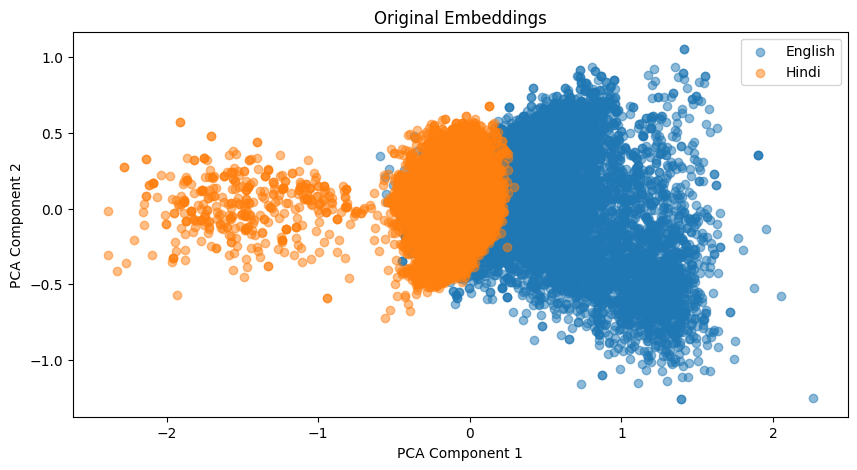

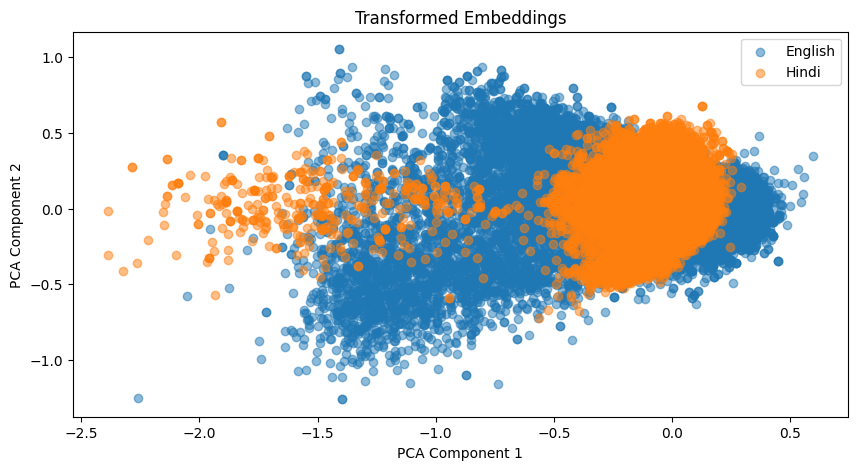

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_embeddings(X_eng, X_hin, title="Embeddings"):
    pca = PCA(n_components=2)
    X_eng_2d = pca.fit_transform(X_eng)
    X_hin_2d = pca.fit_transform(X_hin)

    plt.figure(figsize=(10, 5))
    plt.scatter(X_eng_2d[:, 0], X_eng_2d[:, 1], alpha=0.5, label='English')
    plt.scatter(X_hin_2d[:, 0], X_hin_2d[:, 1], alpha=0.5, label='Hindi')
    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend()
    plt.show()

# Visualize the original embeddings
plot_embeddings(X_eng, X_hin, title="Original Embeddings")

# Visualize the transformed embeddings
X_eng_transformed = apply_transformation(X_eng, W)
plot_embeddings(X_eng_transformed, X_hin, title="Transformed Embeddings")


In [22]:
import numpy as np

def procrustes_alignment_2(X_eng, X_hin):
    # Perform the SVD on X_hin.T @ X_eng
    M = X_eng.T @ X_hin
    U, _, Vt = np.linalg.svd(M)
    
    # Compute orthogonal matrix W
    W = Vt.T @ U.T
    
    return W

# Perform Procrustes alignment
W_2 = procrustes_alignment_2(X_eng, X_hin)


In [23]:
from sklearn.metrics.pairwise import cosine_similarity

# Transform English embeddings using W
def apply_transformation(X_eng, W):
    return X_eng @ W.T

# Compute Precision@k
def precision_at_k(X_src_transformed, X_tgt, k=1):
    num_correct = 0
    similarities = cosine_similarity(X_src_transformed, X_tgt)

    for i in range(similarities.shape[0]):
        # Get indices of the top-k similar target words
        top_k_indices = np.argsort(similarities[i])[::-1][:k]
        
        # Check if the correct target embedding is in the top k
        if i in top_k_indices:
            num_correct += 1

    precision = num_correct / similarities.shape[0] * 100  # percentage
    return precision

# Transform the English embeddings
X_eng_transformed = apply_transformation(X_eng, W_2)

# Evaluate Precision@1, @2, @5
precision_1 = precision_at_k(X_eng_transformed, X_hin, k=1)
precision_5 = precision_at_k(X_eng_transformed, X_hin, k=5)

print(f"Precision@1: {precision_1}%")
print(f"Precision@5: {precision_5}%")


Precision@1: 15.88421052631579%
Precision@5: 34.589473684210525%


Number of pairs: 2000
Precision@1: 0.05%
Precision@5: 0.6%



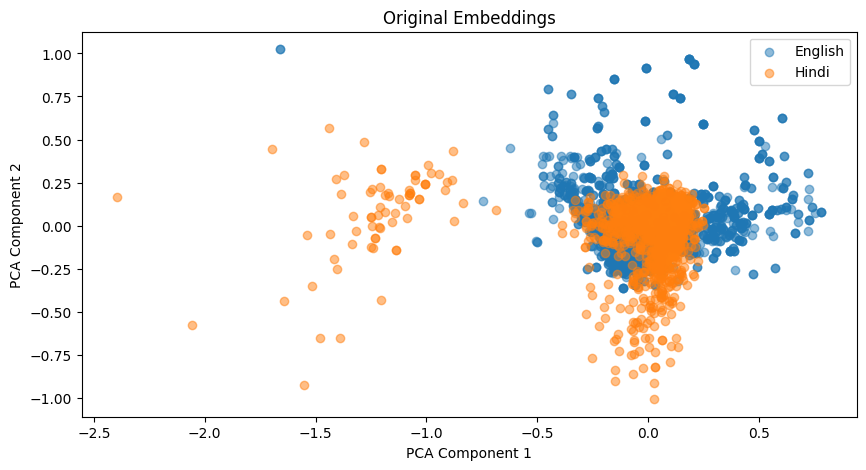

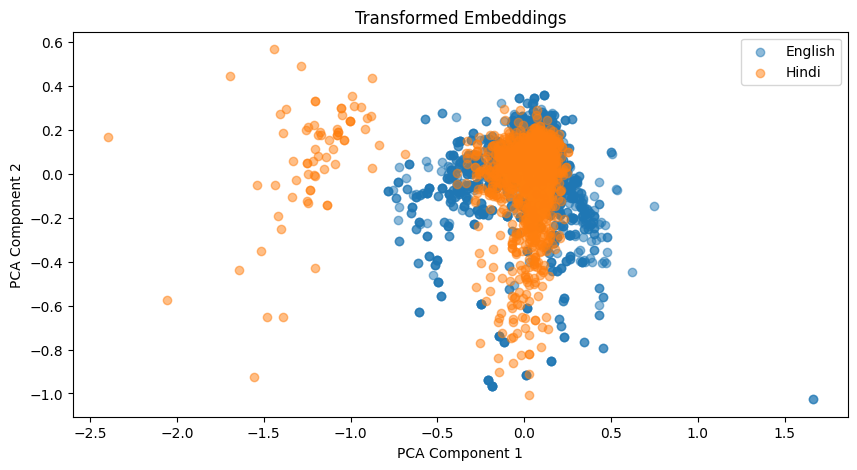

Number of pairs: 5000
Precision@1: 0.02%
Precision@5: 0.13999999999999999%



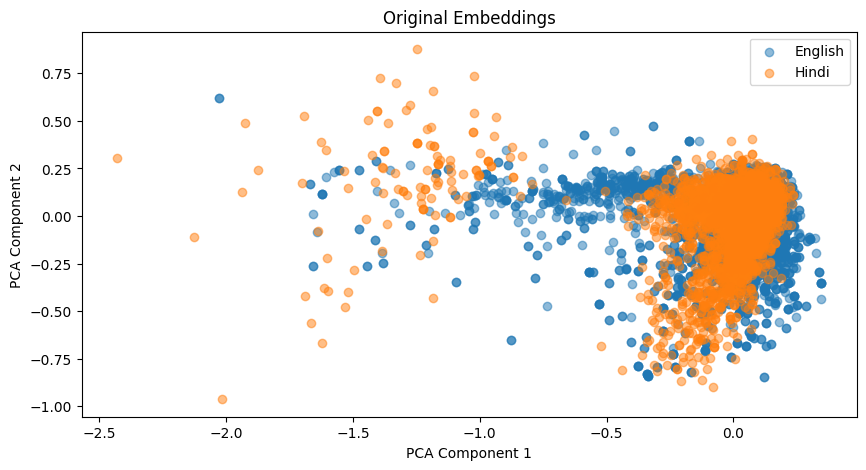

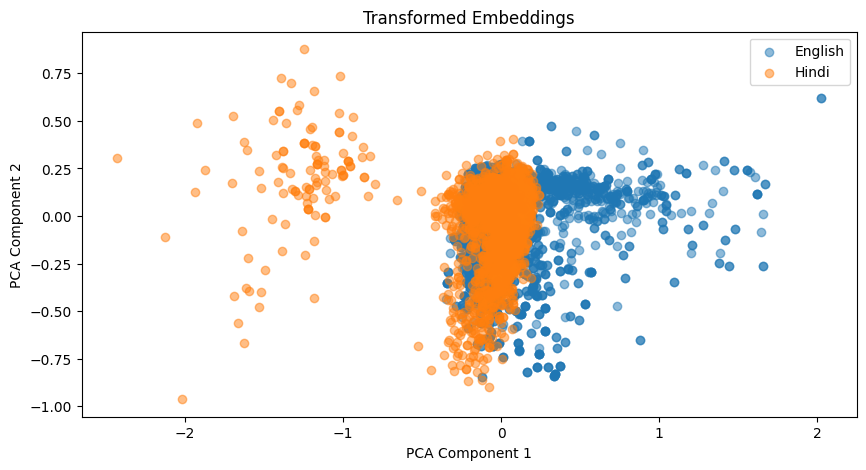

Number of pairs: 10000
Precision@1: 0.0%
Precision@5: 0.04%



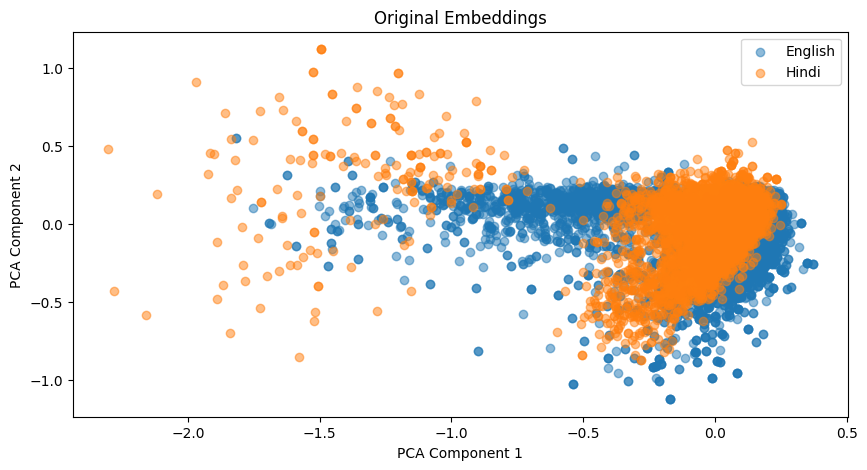

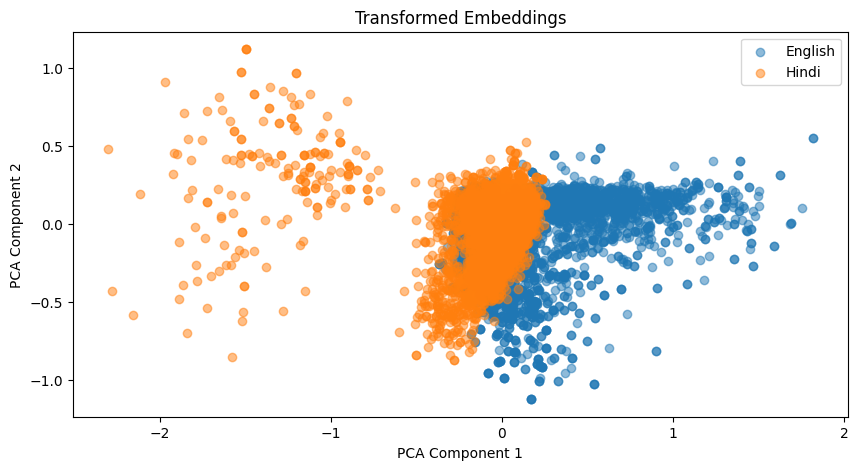

Number of pairs: 20000
Precision@1: 0.01%
Precision@5: 0.03%



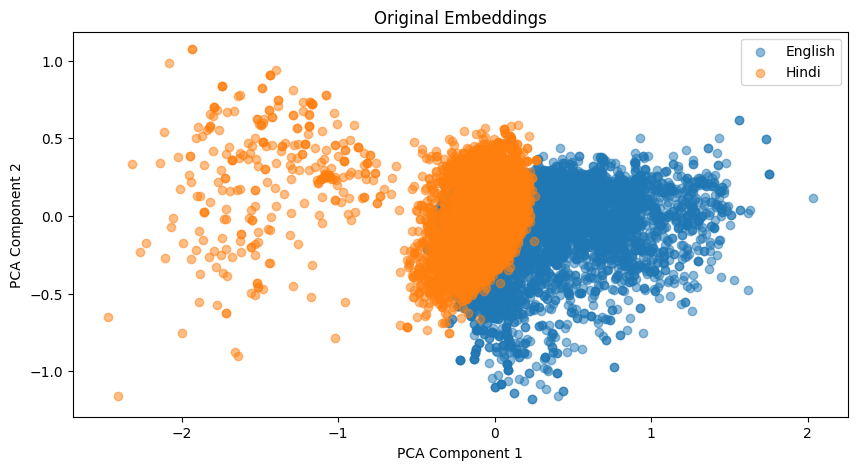

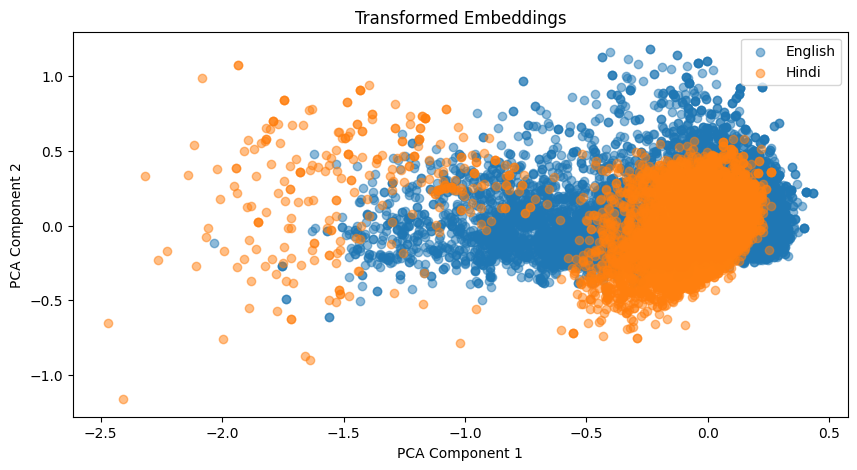

Number of pairs: 30000
Precision@1: 0.0%
Precision@5: 0.016666666666666666%



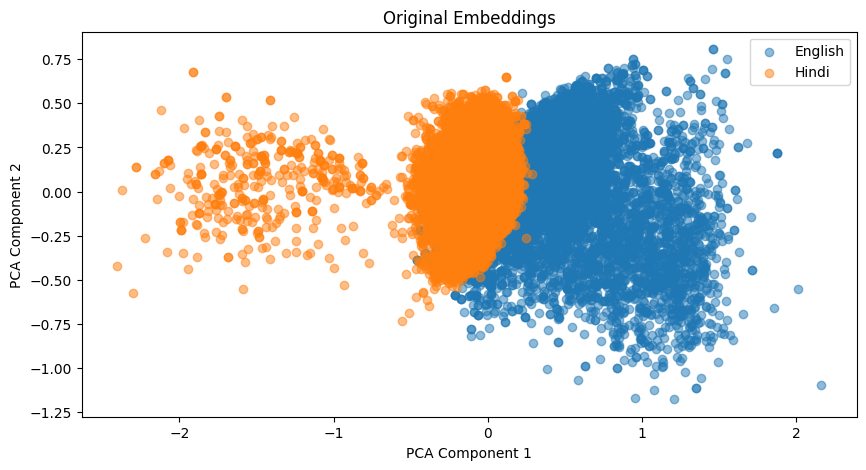

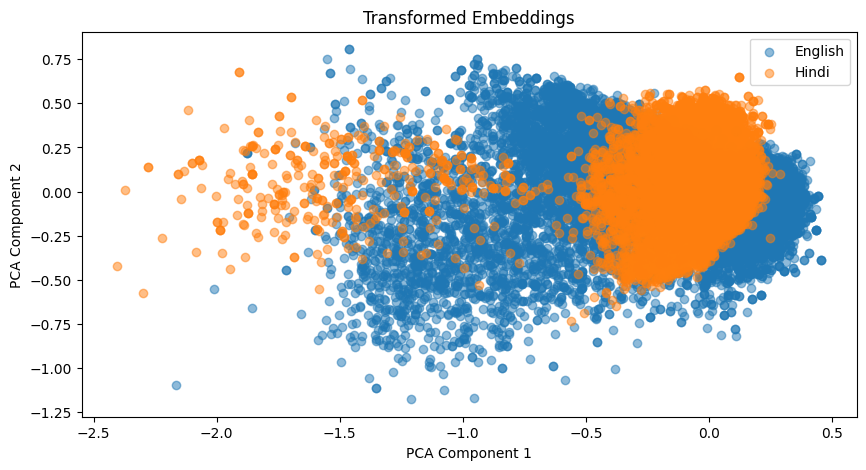

Number of pairs: 38000
Precision@1: 0.002631578947368421%
Precision@5: 0.01842105263157895%



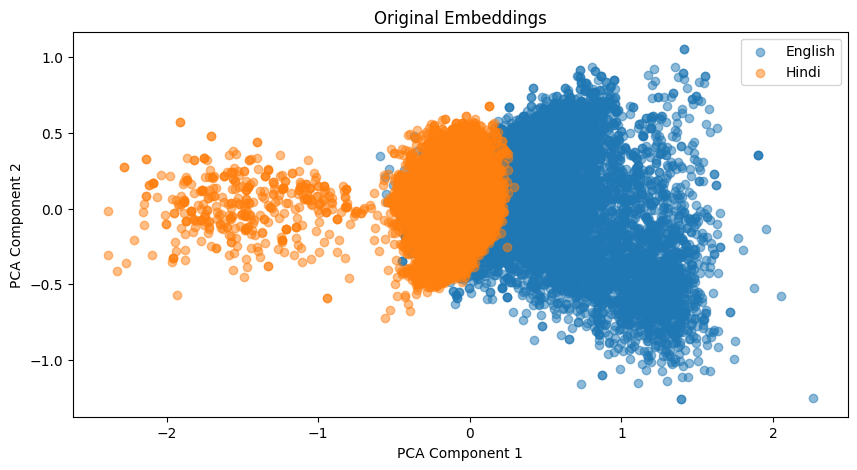

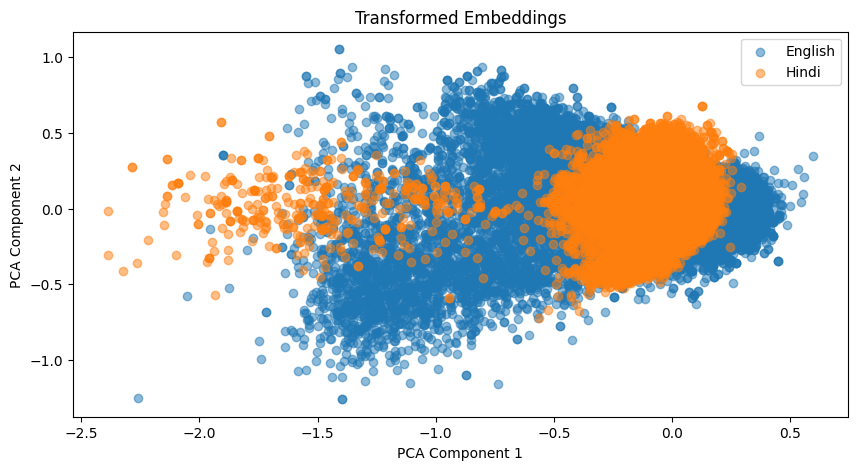

In [57]:
num_pairs = [2000, 5000, 10000, 20000, 30000, 38000]
for num_pair in num_pairs:
    X_eng, X_hin = generate_embeddings(bilingual_lexicon, en_model, hi_model, num_pairs=num_pair)
    W = procrustes_alignment(X_eng, X_hin)
    X_eng_transformed = apply_transformation(X_eng, W)
    precision_1 = precision_at_k(X_eng_transformed, X_hin, k=1)
    precision_5 = precision_at_k(X_eng_transformed, X_hin, k=5)
    print(f"Number of pairs: {num_pair}")
    print(f"Precision@1: {precision_1}%")
    print(f"Precision@5: {precision_5}%")
    print()
    
    # Visualize the original 
    plot_embeddings(X_eng, X_hin, title="Original Embeddings")

    # Visualize the transformed embeddings
    plot_embeddings(X_eng_transformed, X_hin, title="Transformed Embeddings")

    


In [76]:
# find the nearest top 5 words in Hindi for the English word embedding

def find_nearest_words(eng_word, en_model, hi_model, W, top_n=5):
    # Get the English word embedding
    eng_vector = en_model.wv[eng_word]
    
    # Transform the English word embedding
    eng_vector_transformed = np.dot(eng_vector, W)
    
    # computer cosine similarity between the english word embedding and Hindi word embeddings
    similarities_not = np.dot(eng_vector, hi_model.wv.vectors.T)

    # Compute cosine similarity between the transformed English word embedding and Hindi word embeddings
    similarities = np.dot(eng_vector_transformed, hi_model.wv.vectors.T)

    # Get the indices of the top N most similar Hindi words without the English word
    most_similar_indices_not = np.argsort(similarities_not)[-top_n:][::-1]
    
    # Get the indices of the top N most similar Hindi words
    most_similar_indices = np.argsort(similarities)[-top_n:][::-1]
    
    # Get the Hindi words
    hin_words = [hi_model.wv.index_to_key[i] for i in most_similar_indices]

    # Return the Hindi words
    hin_words_not = [hi_model.wv.index_to_key[i] for i in most_similar_indices_not]
    
    return hin_words, hin_words_not


# Find the nearest top 5 Hindi words for 'work'
hin_words, hindi_words_not = find_nearest_words('money', en_model, hi_model, W)
print(f"Before Transformation: {hindi_words_not}")
print(f"After Transformation: {hin_words}") 

Before Transformation: ['बर', 'इज', 'ईस', 'टू', 'सघ']
After Transformation: ['धन', 'रकम', 'रु', 'ऋण', 'कमा']


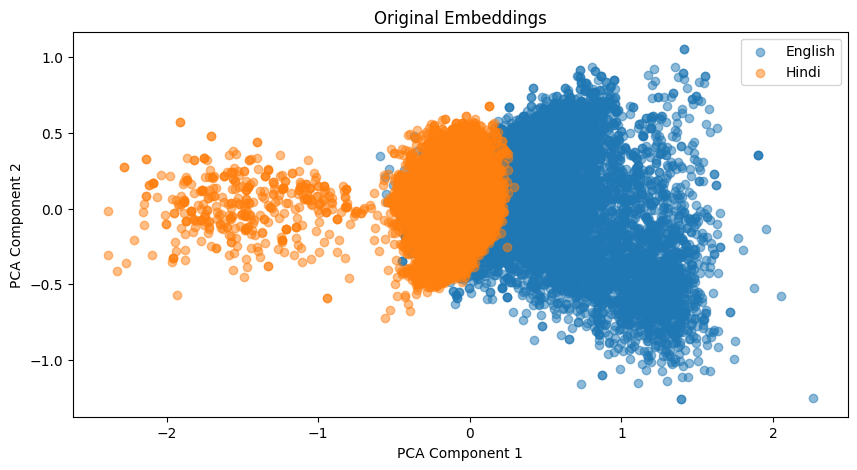

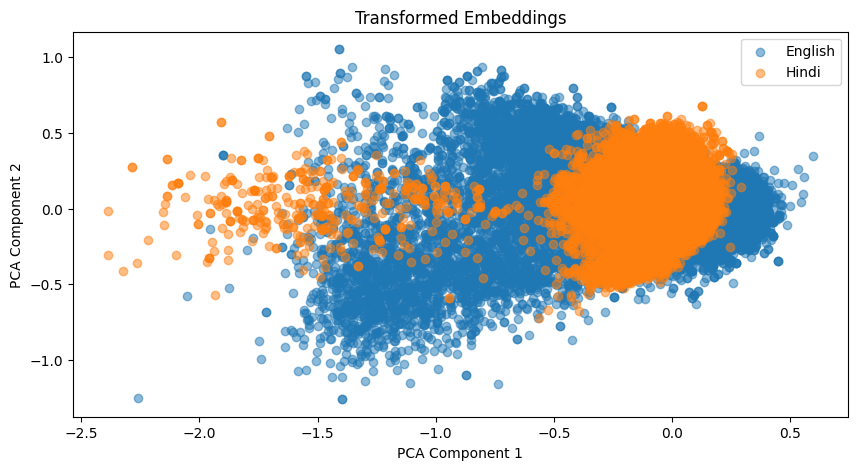

In [38]:
#visualize the embeddings

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_embeddings(X_eng, X_hin, title="Embeddings"):
    pca = PCA(n_components=2)
    X_eng_2d = pca.fit_transform(X_eng)
    X_hin_2d = pca.fit_transform(X_hin)

    plt.figure(figsize=(10, 5))
    plt.scatter(X_eng_2d[:, 0], X_eng_2d[:, 1], alpha=0.5, label='English')
    plt.scatter(X_hin_2d[:, 0], X_hin_2d[:, 1], alpha=0.5, label='Hindi')
    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend()
    plt.show()  

# Visualize the original embeddings
plot_embeddings(X_eng, X_hin, title="Original Embeddings")

# Visualize the transformed embeddings
X_eng_transformed = apply_transformation(X_eng, W)
plot_embeddings(X_eng_transformed, X_hin, title="Transformed Embeddings")



In [79]:
import gensim
new_model = gensim.models.KeyedVectors.load_word2vec_format('cc.en.300.vec\cc.en.300.vec')



yes


In [102]:
# checkout how many words are in the model

hi_vec_model = gensim.models.KeyedVectors.load_word2vec_format('cc.hi.300.vec\cc.hi.300.vec')
hi_vec_model.vectors.shape

(1876653, 300)